In [84]:
# ==========================================
# MUSHROOM DATA ANALYSIS + MODELING COLAB
# ==========================================

# 1️⃣ IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# For Colab file upload/download
from google.colab import files

In [85]:
df = pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [86]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [87]:
df.drop('class', axis=1)

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


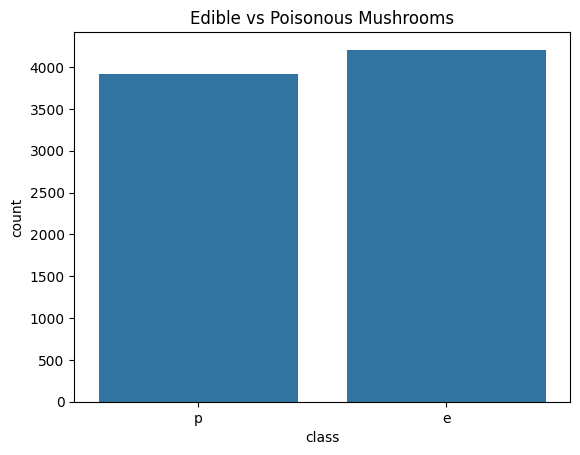

In [88]:
# Class distribution
sns.countplot(x="class", data=df)
plt.title("Edible vs Poisonous Mushrooms")
plt.show()


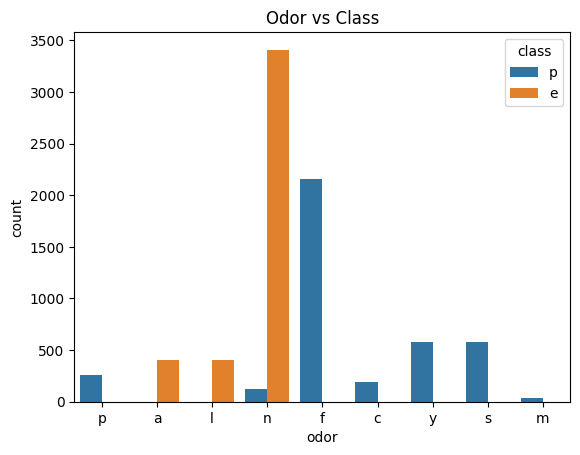

In [89]:
# Bar plot of odors
sns.countplot(x="odor", hue="class", data=df)
plt.title("Odor vs Class")
plt.show()


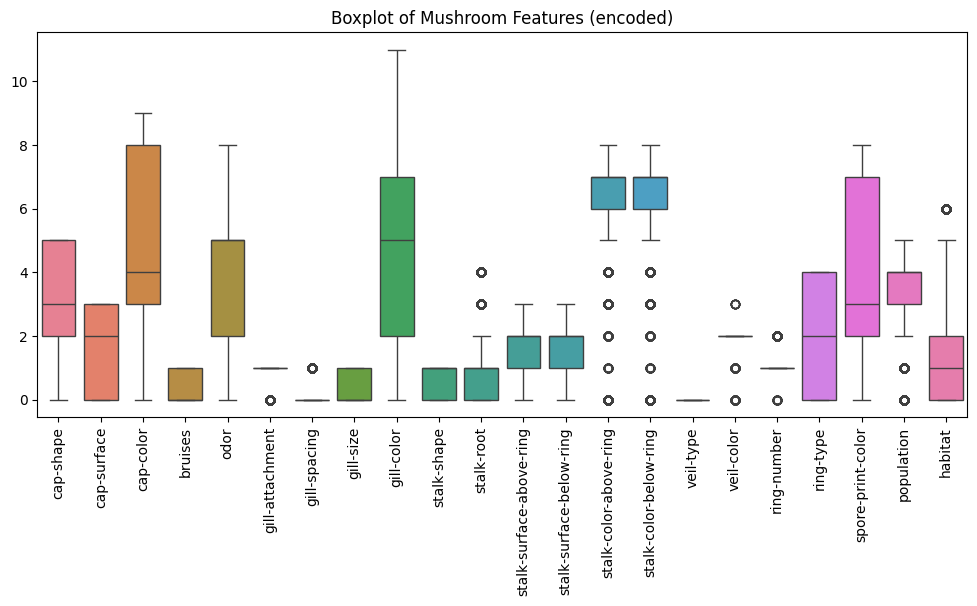

In [90]:
# Boxplot example: convert categorical to codes temporarily
df_numeric = df.apply(lambda x: pd.Categorical(x).codes)
plt.figure(figsize=(12,5))
sns.boxplot(data=df_numeric.drop("class", axis=1))
plt.xticks(rotation=90)
plt.title("Boxplot of Mushroom Features (encoded)")
plt.show()

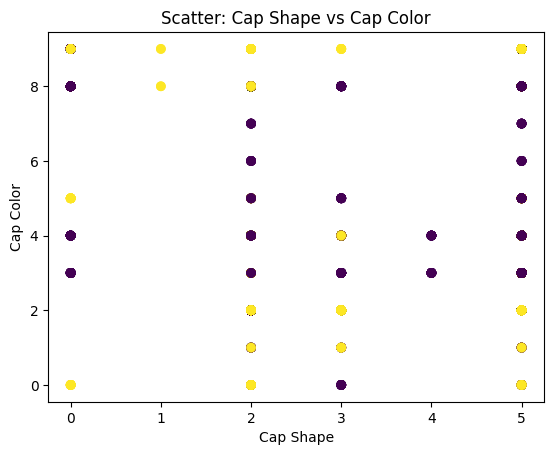

In [91]:
# Scatter plot example: pick two numeric features
plt.scatter(df_numeric["cap-shape"], df_numeric["cap-color"], c=df_numeric["class"])
plt.xlabel("Cap Shape")
plt.ylabel("Cap Color")
plt.title("Scatter: Cap Shape vs Cap Color")
plt.show()

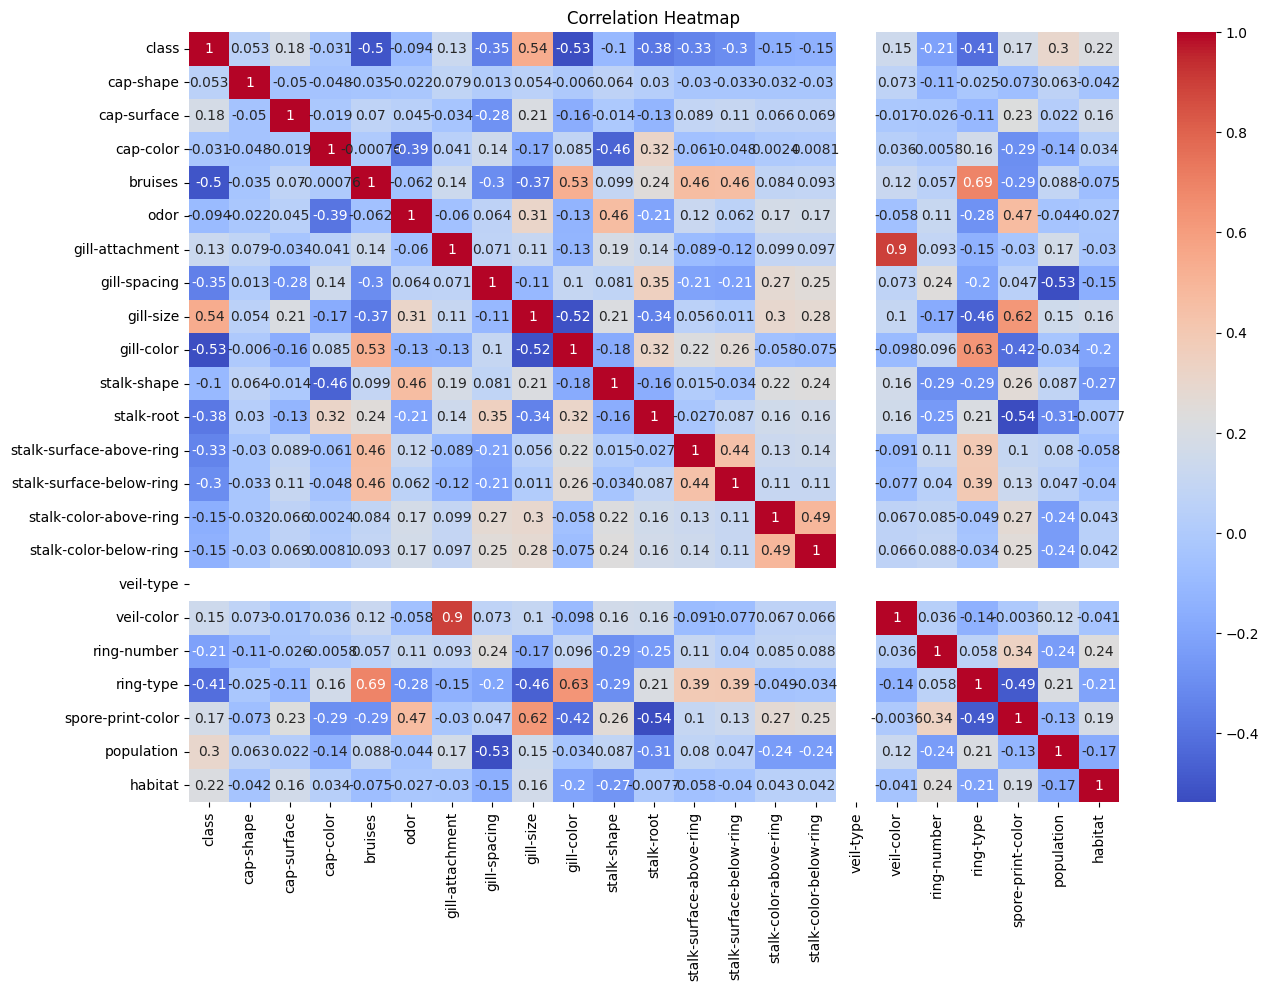

In [92]:
# Heatmap of feature correlations
plt.figure(figsize=(15,10))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [93]:
X = df.drop("class", axis=1)
y = df["class"].map({"e":0, "p":1})  # 0 = Edible, 1 = Poisonous


encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

In [94]:
# 5️⃣ DECISION TREE MODEL
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.9772307692307692
[[833  10]
 [ 27 755]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       843
           1       0.99      0.97      0.98       782

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



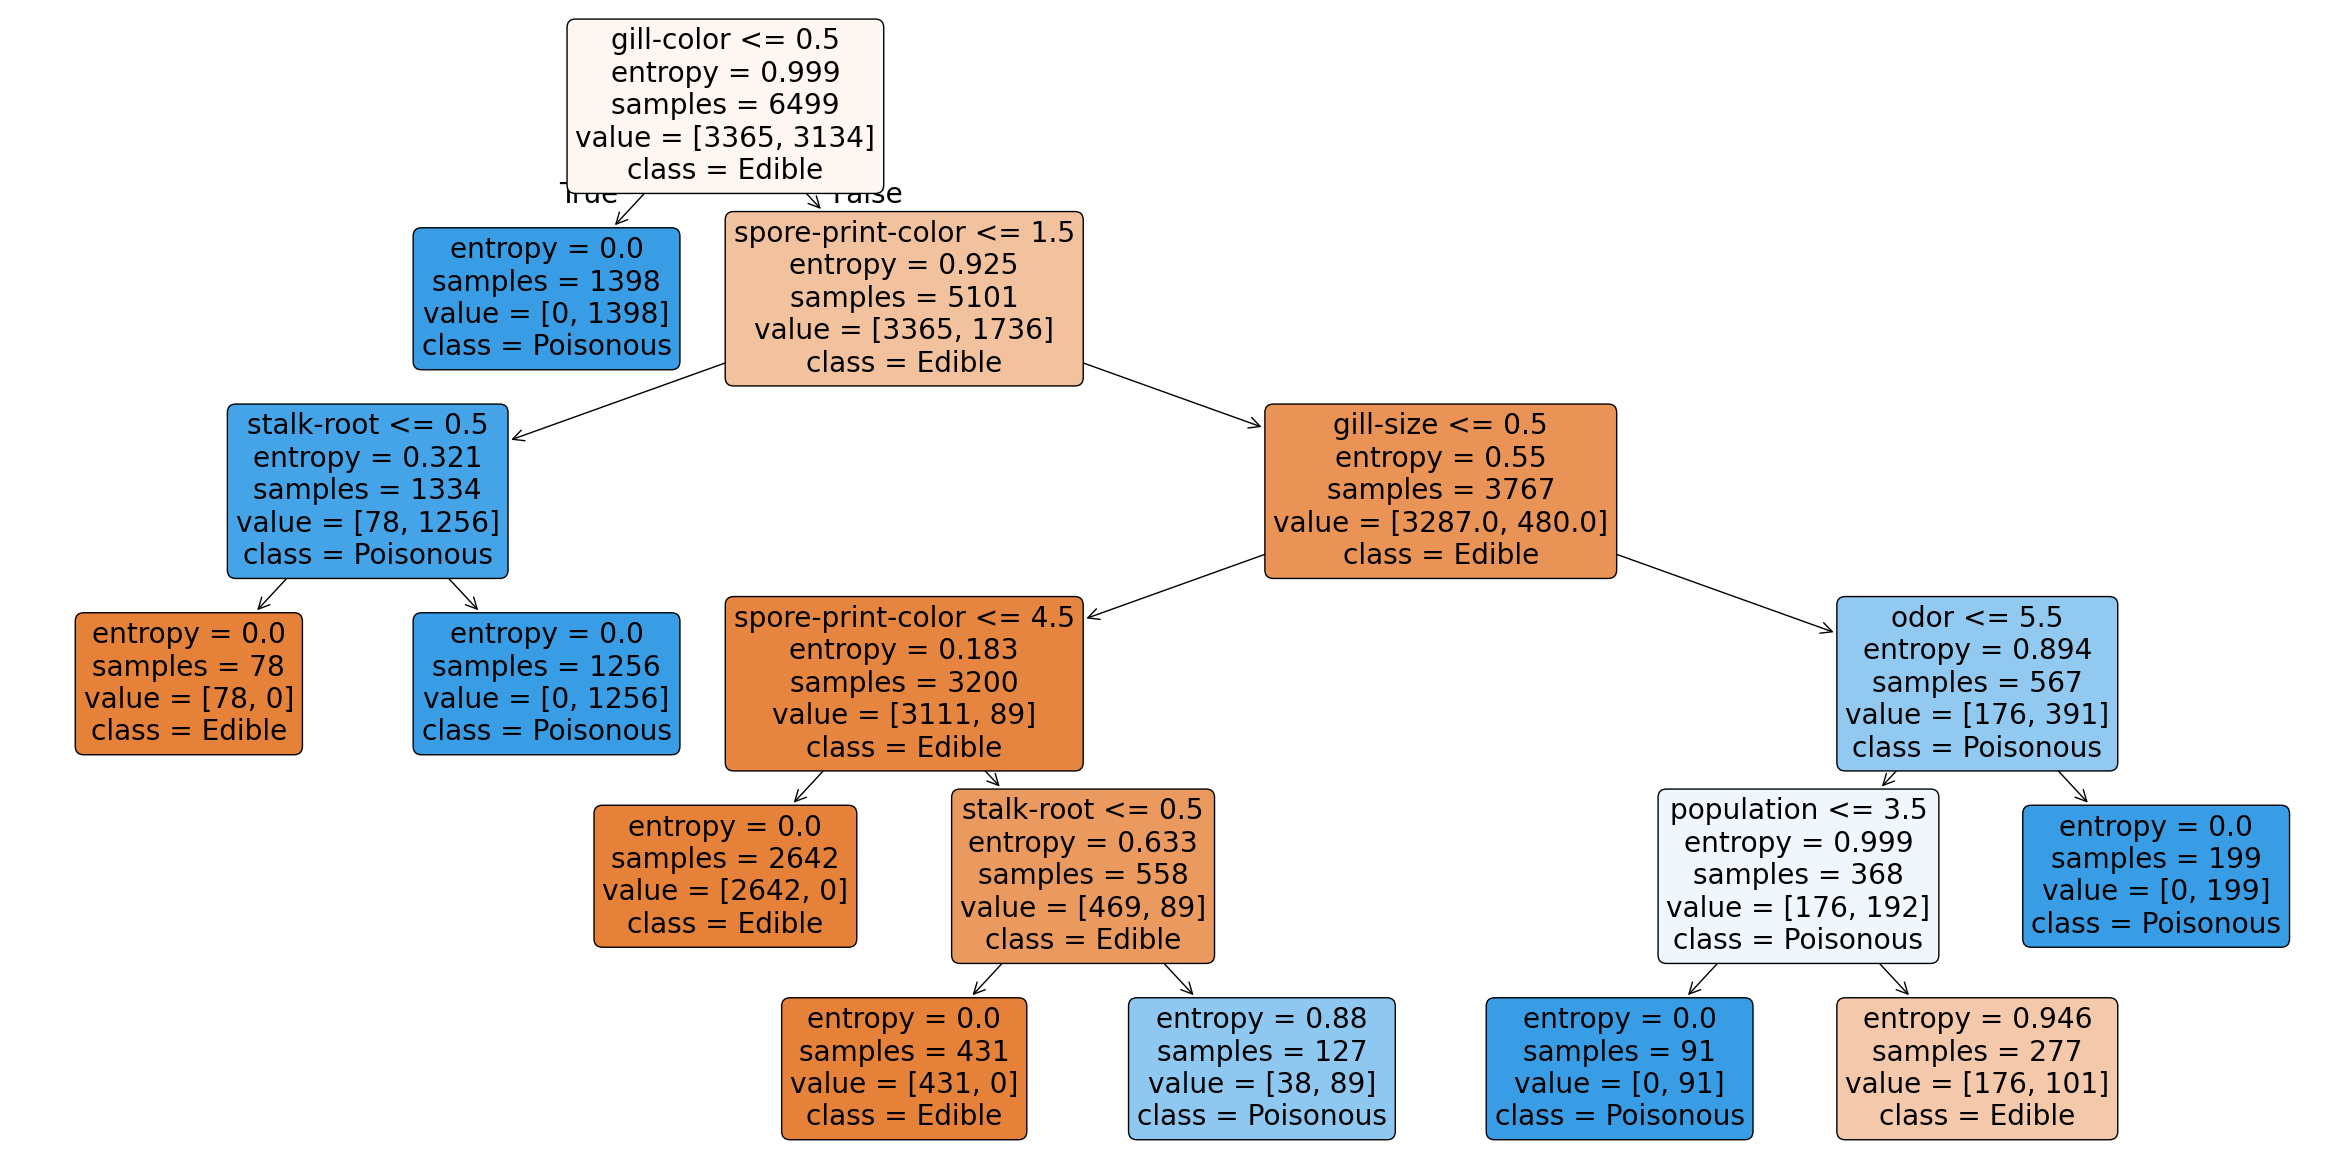

In [95]:
# Plot Decision Tree
plt.figure(figsize=(30,15))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Edible","Poisonous"],
    filled=True,
    rounded=True
)
plt.show()

In [96]:
# ==========================================
# 6️⃣ KMEANS CLUSTERING (unsupervised)
# ==========================================
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_encoded)

KMeans(n_clusters=2, random_state=42)

In [97]:
labels = kmeans.labels_
# Compare with actual class
print("KMeans accuracy approx (label matching):", accuracy_score(y, labels))

KMeans accuracy approx (label matching): 0.7090103397341211


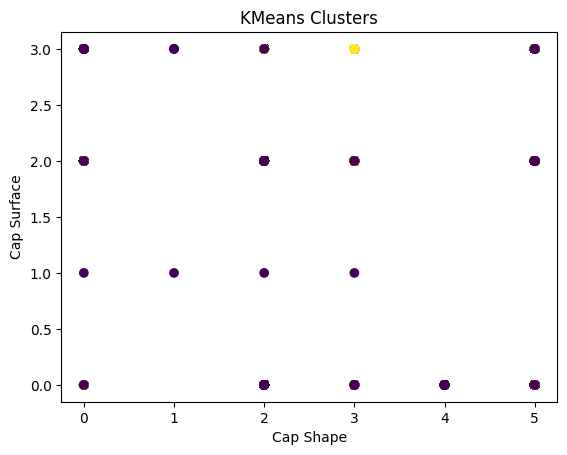

In [98]:
# Scatter of first two features
plt.scatter(X_encoded[:,0], X_encoded[:,1], c=labels, cmap='viridis')
plt.xlabel("Cap Shape")
plt.ylabel("Cap Surface")
plt.title("KMeans Clusters")
plt.show()


In [99]:
# ==========================================
# 7️⃣ SAVE MODELS & ENCODER (FOR FLASK)
# ==========================================
joblib.dump(dt_model, "decision_tree_mushroom.pkl")
joblib.dump(encoder, "mushroom_encoder.pkl")
print("Models saved!")

# Download the .pkl files
files.download("decision_tree_mushroom.pkl")
files.download("mushroom_encoder.pkl")

Models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>